# Combined Bar Chart - Text-Vision CVCL vs CLIP Across Same-Class Discrimination Tests (No Black/White)

This notebook creates a horizontal bar chart comparing model performance across SCDC (color), SCDS (size), and SCDT (texture) discrimination tests using text-vision alignment.

**MODIFICATION**: This version uses results from tests that excluded black and white colors to focus on chromatic color discrimination.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Path setup
REPO_ROOT = r'C:\Users\jbats\Projects\NTU-Synthetic'
RESULTS_DIR = os.path.join(REPO_ROOT, 'PatrickProject', 'Chart_Generation', 'Textvision')
OUTPUT_DIR = os.path.join(REPO_ROOT, 'PatrickProject', 'Chart_Generation', 'Textvision', 'BlackwhiteChart')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load all three CSV files from noblackwhite tests
scdc_df = pd.read_csv(os.path.join(RESULTS_DIR, 'scdc_textvision_perclass_noblackwhite_summary.csv'))
scds_df = pd.read_csv(os.path.join(RESULTS_DIR, 'scds_textvision_perclass_noblackwhite_summary.csv'))
scdt_df = pd.read_csv(os.path.join(RESULTS_DIR, 'scdt_textvision_perclass_noblackwhite_summary.csv'))

print("Loaded text-vision data (No Black/White):")
print(f"SCDC shape: {scdc_df.shape}")
print(f"SCDS shape: {scds_df.shape}")
print(f"SCDT shape: {scdt_df.shape}")

# Check columns
print("\nColumns in SCDC:")
print(scdc_df.columns.tolist())
print("\nFirst few rows of SCDC:")
print(scdc_df.head())

Loaded text-vision data (No Black/White):
SCDC shape: (132, 8)
SCDS shape: (132, 8)
SCDT shape: (132, 8)

Columns in SCDC:
['model', 'class', 'mean_accuracy', 'std', 'se', 'ci95', 'n_seeds', 'total_trials']

First few rows of SCDC:
          model     class  mean_accuracy       std        se      ci95  \
0  cvcl-resnext  headband       0.244444  0.004811  0.002778  0.005444   
1  cvcl-resnext    abacus       0.263889  0.031549  0.018215  0.035702   
2  cvcl-resnext    camera       0.236111  0.012729  0.007349  0.014405   
3  cvcl-resnext  ornament       0.297222  0.067871  0.039185  0.076803   
4  cvcl-resnext      doll       0.250000  0.025000  0.014434  0.028290   

   n_seeds  total_trials  
0        3          1500  
1        3          1500  
2        3          1500  
3        3          1500  
4        3          1500  


In [5]:
# Calculate statistics for each test and model
def calculate_stats(df, test_name):
    """Calculate mean and std for each model in a test."""
    stats = {}
    
    for model in df['model'].unique():
        model_data = df[df['model'] == model]['mean_accuracy'].values
        
        # Calculate overall mean and standard error
        mean_acc = np.mean(model_data) * 100  # Convert to percentage
        std_acc = np.std(model_data) * 100
        
        # Standard error for error bars
        n_samples = len(model_data)
        se = std_acc / np.sqrt(n_samples)
        ci95 = 1.96 * se  # 95% confidence interval
        
        stats[model] = {
            'mean': mean_acc,
            'std': std_acc,
            'se': se,
            'ci95': ci95,
            'n': n_samples
        }
    
    return stats

# Calculate stats for each test
scdc_stats = calculate_stats(scdc_df, 'SCDC (Color)')
scds_stats = calculate_stats(scds_df, 'SCDS (Size)')
scdt_stats = calculate_stats(scdt_df, 'SCDT (Texture)')

# Print summary
print("Text-Vision Summary Statistics:\n")
print("SCDC (Color Discrimination):")
for model, stats in scdc_stats.items():
    print(f"  {model}: {stats['mean']:.1f}% ± {stats['ci95']:.1f}%")

print("\nSCDS (Size Discrimination):")
for model, stats in scds_stats.items():
    print(f"  {model}: {stats['mean']:.1f}% ± {stats['ci95']:.1f}%")

print("\nSCDT (Texture Discrimination):")
for model, stats in scdt_stats.items():
    print(f"  {model}: {stats['mean']:.1f}% ± {stats['ci95']:.1f}%")

Text-Vision Summary Statistics:

SCDC (Color Discrimination):
  cvcl-resnext: 24.9% ± 0.8%
  clip-res: 97.6% ± 0.9%

SCDS (Size Discrimination):
  cvcl-resnext: 27.2% ± 1.6%
  clip-res: 30.5% ± 1.4%

SCDT (Texture Discrimination):
  cvcl-resnext: 28.3% ± 1.9%
  clip-res: 28.6% ± 1.4%


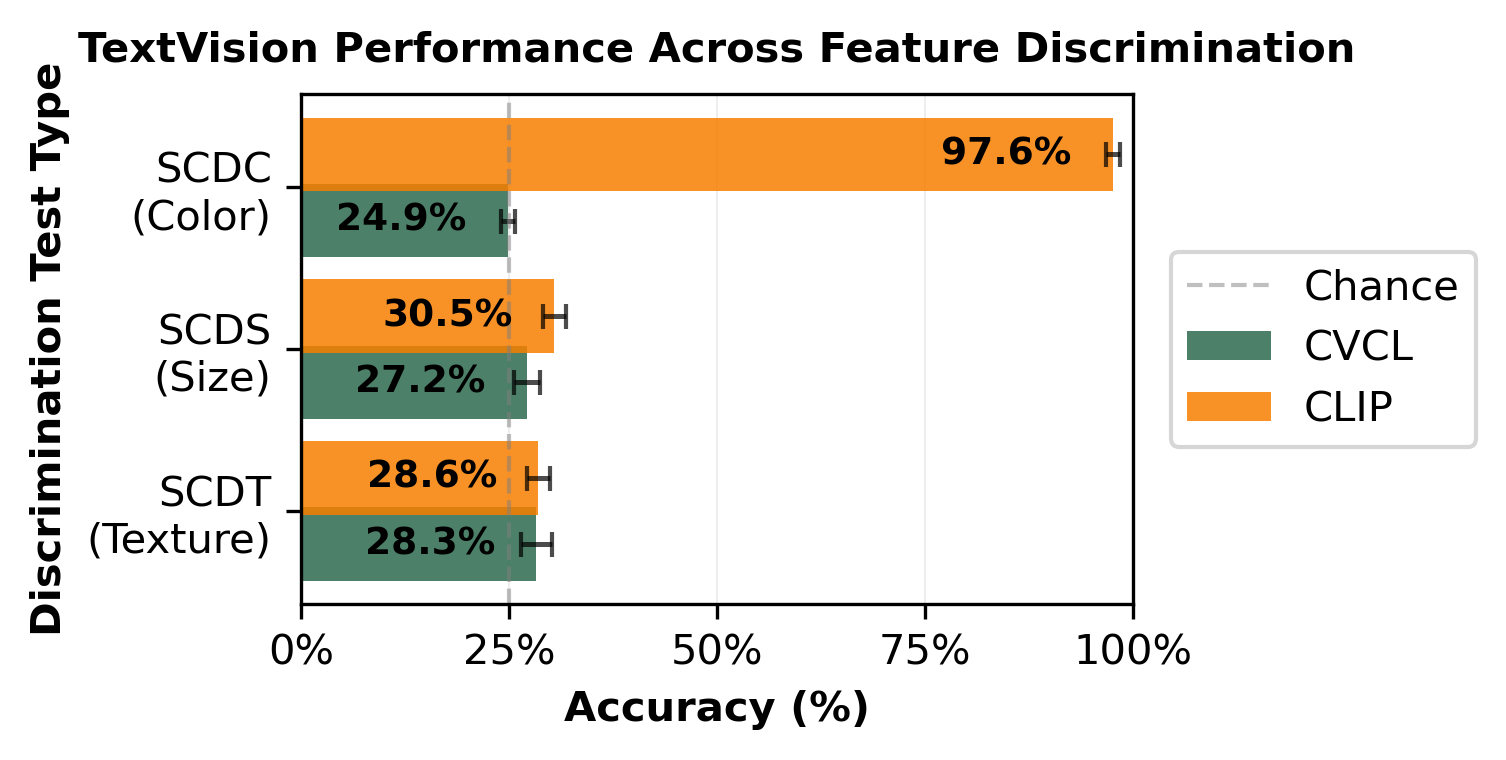


Saved:
  C:\Users\jbats\Projects\NTU-Synthetic\PatrickProject\Chart_Generation\Textvision\BlackwhiteChart\textvision_combined_discrimination_noblackwhite_results.png
  C:\Users\jbats\Projects\NTU-Synthetic\PatrickProject\Chart_Generation\Textvision\BlackwhiteChart\textvision_combined_discrimination_noblackwhite_results.pdf


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

# --- size & style knobs ---
FIG_W, FIG_H = 5, 2.5      # smaller overall figure
BAR_H = 0.22               # thinner bars
TITLE_FS = 10              # title font size
LABEL_FS = 10              # axis label font size
TICK_FS  = 10              # tick label font size
LEGEND_FS = 10             # legend font size
ANNOT_FS = 9               # numbers inside bars
ANNOT_OFFSET = 5           # fixed offset to move annotations left

# Ensure output dir exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H), dpi=300)

# Setup data for plotting
tests = ['SCDT\n(Texture)', 'SCDS\n(Size)', 'SCDC\n(Color)']  # bottom->top
test_stats = [scdt_stats, scds_stats, scdc_stats]              # same order

# Model colors
colors = {
    'cvcl-resnext': '#2d6a4f',
    'clip-res': '#f77f00'
}

bar_height = BAR_H
y_positions = np.arange(len(tests)) * (bar_height * 2.2)  # tighter spacing

# Bars for each model
for i, (test_name, stats) in enumerate(zip(tests, test_stats)):
    # CVCL
    if 'cvcl-resnext' in stats:
        cvcl_mean = stats['cvcl-resnext']['mean']
        cvcl_error = stats['cvcl-resnext']['ci95']
        ax.barh(y_positions[i] - bar_height*0.45, cvcl_mean, bar_height,
                xerr=cvcl_error,
                color=colors['cvcl-resnext'], alpha=0.85,
                label='CVCL' if i == 0 else None, capsize=3,
                error_kw={'linewidth': 1.2, 'ecolor': 'black', 'alpha': 0.7})
        ax.text(cvcl_mean - ANNOT_OFFSET, y_positions[i] - bar_height*0.45,
                f'{cvcl_mean:.1f}%', va='center', ha='right',
                fontsize=ANNOT_FS, fontweight='bold', color='black')

    # CLIP
    if 'clip-res' in stats:
        clip_mean = stats['clip-res']['mean']
        clip_error = stats['clip-res']['ci95']
        ax.barh(y_positions[i] + bar_height*0.45, clip_mean, bar_height,
                xerr=clip_error,
                color=colors['clip-res'], alpha=0.85,
                label='CLIP' if i == 0 else None, capsize=3,
                error_kw={'linewidth': 1.2, 'ecolor': 'black', 'alpha': 0.7})
        ax.text(clip_mean - ANNOT_OFFSET, y_positions[i] + bar_height*0.45,
                f'{clip_mean:.1f}%', va='center', ha='right',
                fontsize=ANNOT_FS, fontweight='bold', color='black')

# Formatting
ax.set_ylabel('Discrimination Test Type', fontsize=LABEL_FS, fontweight='bold', labelpad=4)
ax.set_xlabel('Accuracy (%)', fontsize=LABEL_FS, fontweight='bold', labelpad=4)
ax.set_title('TextVision Performance Across Feature Discrimination',
             fontsize=TITLE_FS, fontweight='bold', pad=8)

ax.set_yticks(y_positions)
ax.set_yticklabels(tests, fontsize=TICK_FS)
ax.tick_params(axis='x', labelsize=TICK_FS)

ax.set_xlim(0, 100)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(['0%', '25%', '50%', '75%', '100%'], fontsize=TICK_FS)

# Chance line
ax.axvline(x=25, color='gray', linestyle='--', alpha=0.5, linewidth=1.0, label='Chance')

# Grid
ax.grid(axis='x', alpha=0.25, linestyle='-', linewidth=0.4)
ax.set_axisbelow(True)

# Legend OUTSIDE on the right
leg = ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    fontsize=LEGEND_FS,
    frameon=True, fancybox=True, shadow=False
)

# Leave room on right so legend isn't cropped
fig.subplots_adjust(right=0.80)
plt.tight_layout(pad=0.6)

# Save
png_path = os.path.join(OUTPUT_DIR, 'textvision_combined_discrimination_noblackwhite_results.png')
pdf_path = os.path.join(OUTPUT_DIR, 'textvision_combined_discrimination_noblackwhite_results.pdf')
plt.savefig(png_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(pdf_path, bbox_inches='tight', facecolor='white')
plt.show()

print("\nSaved:")
print(" ", os.path.abspath(png_path))
print(" ", os.path.abspath(pdf_path))